#  Dataset Exploration (Spider)

**Sub-problem B**

Before we can generate a single agent trajectory we need to understand the data
the agent will be working against. This notebook answers four questions:

1. **What is in our three databases?** Tables, rows, foreign keys.
2. **How much prompt does each schema cost?** This directly sets the token
   budget for the ReAct loop on an 8 GB card.
3. **Are our 60 curated questions sensible?** Difficulty balance, SQL
   complexity, and whether the difficulty heuristic actually means anything.
4. **Are the two training domains different enough from the holdout** for the
   generalisation experiment to be meaningful?


In [1]:
import json, sqlite3, re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

ROOT   = Path("..") if Path("../data").exists() else Path(".")
DB_DIR = ROOT / "data" / "db"
TASKS  = ROOT / "data" / "tasks"

tasks   = pd.DataFrame(json.load(open(TASKS / "task_suite.json")))
schemas = json.load(open(TASKS / "schemas.json"))

print(f"{len(tasks)} tasks across {tasks.db.nunique()} databases")
tasks.head()

Matplotlib is building the font cache; this may take a moment.


60 tasks across 3 databases


,task_id,question,gold_sql,difficulty,db,split,tags,source,n_tables,n_joins
0,t001,Find names of instructors with salary greater ...,SELECT name FROM instructor WHERE salary > (SE...,medium,college_2,main,"[aggregation, filter, subquery]",spider,1,0
1,t002,"Find the id, forename and number of races of a...","SELECT T1.driverid , T1.forename , count(*) FR...",hard,formula_1,main,"[aggregation, join, groupby, having]",spider,3,2
2,t003,What are the names and years of all races that...,"SELECT T2.name , T2.year FROM results AS T1 JO...",medium,formula_1,main,"[join, filter]",spider,3,2
3,t004,Find courses that ran in Fall 2009 and in Spri...,SELECT course_id FROM SECTION WHERE semester =...,medium,college_2,main,"[filter, subquery, setop]",spider,1,0
4,t005,"List the distinct names of the instructors, or...",SELECT DISTINCT name FROM instructor ORDER BY ...,easy,college_2,main,[sort],spider,1,0


---
## 1. What is in the databases?

Three databases, deliberately from unrelated domains — motorsport, university
records, and a music store. They are kept as **separate SQLite files** rather
than merged: merging would put ~35 tables into every prompt, most of them
irrelevant to any given question.

In [2]:
rows = []
for db, s in schemas.items():
    rows.append({
        "database": db,
        "tables": len(s["tables"]),
        "rows": s["total_rows"],
        "foreign_keys": len(s["foreign_keys"]),
        "columns": sum(len(t["columns"]) for t in s["tables"].values()),
    })
overview = pd.DataFrame(rows).sort_values("tables", ascending=False)
overview

,database,tables,rows,foreign_keys,columns
0,formula_1,13,88380,17,94
1,college_2,11,34620,20,46
2,chinook_1,11,15607,11,64


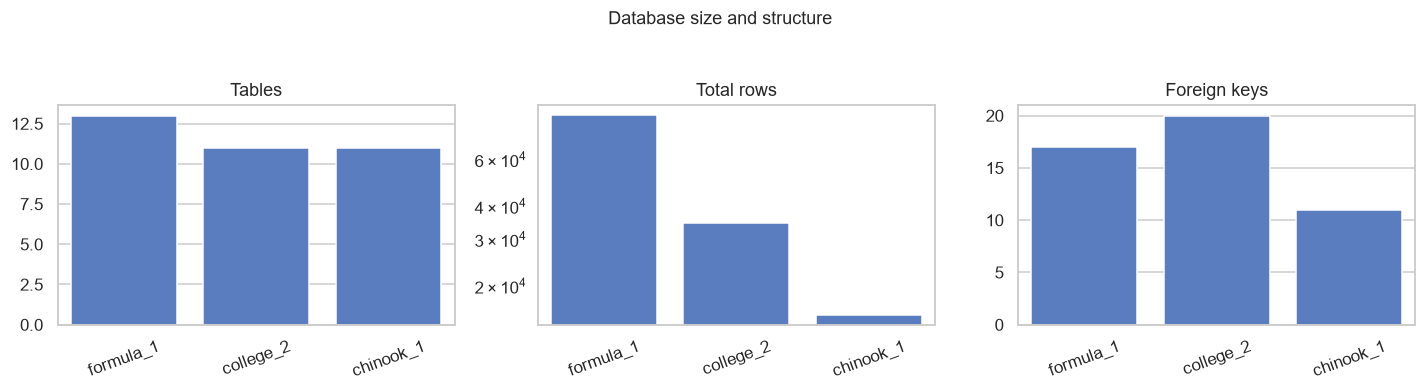

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, title in zip(
        axes,
        ["tables", "rows", "foreign_keys"],
        ["Tables", "Total rows", "Foreign keys"]):
    sns.barplot(overview, x="database", y=col, ax=ax)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
axes[1].set_yscale("log")
plt.suptitle("Database size and structure", y=1.04, fontsize=12)
plt.tight_layout(); plt.show()

### Table sizes within each database

Worth knowing which tables are large: a `SELECT *` against one of these is what
blows up the context window, and it is why the tool contract caps `data` at 20
rows.

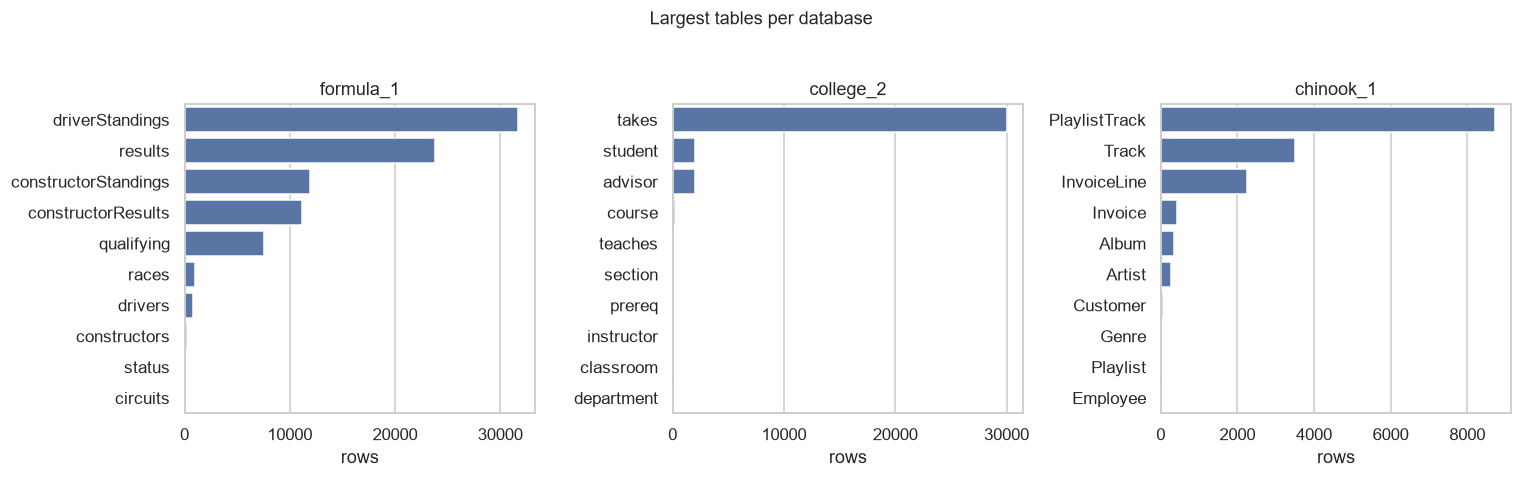

Biggest single table overall:
 database                table  rows  columns
formula_1      driverStandings 31726        7
college_2                takes 30000        6
formula_1              results 23777       18
formula_1 constructorStandings 11896        7
formula_1   constructorResults 11142        5


In [4]:
rows = []
for db, s in schemas.items():
    for t, info in s["tables"].items():
        rows.append({"database": db, "table": t,
                     "rows": info["rows"], "columns": len(info["columns"])})
tbl = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, db in zip(axes, schemas):
    d = tbl[tbl.database == db].sort_values("rows", ascending=False).head(10)
    sns.barplot(d, y="table", x="rows", ax=ax, color="#4C72B0")
    ax.set_title(db); ax.set_xlabel("rows"); ax.set_ylabel("")
plt.suptitle("Largest tables per database", y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

print("Biggest single table overall:")
print(tbl.nlargest(5, "rows").to_string(index=False))

---
## 2. How much prompt does each schema cost?

This is the number that matters most for sub-problem B.

The agent has to be told what tables exist. On an 8 GB card running a 4-bit 7B,
roughly 3 GB is left for the KV cache after the weights — so every token spent
on schema is a token unavailable for reasoning and observations.

We estimate two options:

- **Full schema in the prompt** — every table and column, every step
- **Schema on demand** — table names only, with a `get_schema(table)` tool

Token estimate uses ~4 characters per token, which is close enough for
budgeting.

In [5]:
def schema_text(s, full=True):
    if not full:
        return "Tables: " + ", ".join(s["tables"])
    parts = []
    for t, info in s["tables"].items():
        cols = ", ".join(f'{c["name"]} {c["type"]}' for c in info["columns"])
        parts.append(f"{t}({cols})")
    fks = [f'{f["from_table"]}.{f["from_col"]} -> {f["to_table"]}.{f["to_col"]}'
           for f in s["foreign_keys"]]
    return "\n".join(parts) + "\nForeign keys: " + "; ".join(fks)

est = lambda txt: len(txt) // 4      # ~4 chars per token

cost = pd.DataFrame([{
    "database": db,
    "full_schema_tokens": est(schema_text(s, True)),
    "names_only_tokens": est(schema_text(s, False)),
} for db, s in schemas.items()])
cost["saving"] = cost.full_schema_tokens - cost.names_only_tokens
cost["saving_pct"] = (100 * cost.saving / cost.full_schema_tokens).round(1)
cost

,database,full_schema_tokens,names_only_tokens,saving,saving_pct
0,formula_1,597,40,557,93.3
1,college_2,441,27,414,93.9
2,chinook_1,465,28,437,94.0


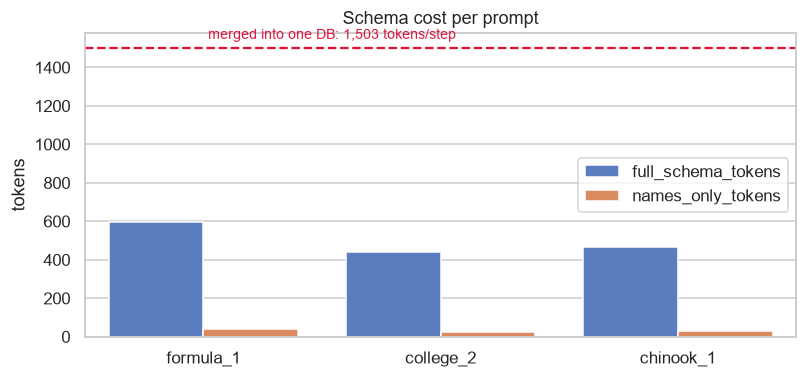

Merged (rejected design): 1,503 tokens on EVERY step
Separate, full schema:    501 avg
Separate, names only:     32 avg

Over a 10-step run, merged costs ~15,030 tokens of schema alone.


In [6]:
MERGED = sum(cost.full_schema_tokens)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
d = cost.melt(id_vars="database",
              value_vars=["full_schema_tokens", "names_only_tokens"],
              var_name="strategy", value_name="tokens")
sns.barplot(d, x="database", y="tokens", hue="strategy", ax=ax)
ax.axhline(MERGED, ls="--", c="crimson")
ax.text(0.02, MERGED * 1.03, f"merged into one DB: {MERGED:,} tokens/step",
        color="crimson", fontsize=9)
ax.set_title("Schema cost per prompt"); ax.set_xlabel(""); ax.set_ylabel("tokens")
ax.legend(title="")
plt.tight_layout(); plt.show()

print(f"Merged (rejected design): {MERGED:,} tokens on EVERY step")
print(f"Separate, full schema:    {cost.full_schema_tokens.mean():.0f} avg")
print(f"Separate, names only:     {cost.names_only_tokens.mean():.0f} avg")
print()
print(f"Over a 10-step run, merged costs ~{MERGED*10:,} tokens of schema alone.")

**Finding.** Merging the three databases would cost roughly the full schema
budget of all three on every step — for a question that only ever needs one of
them. Keeping them separate is worth a large fraction of the context window,
and schema-on-demand saves most of what remains.

This is the empirical justification for two design decisions: separate
databases, and the `get_schema(table)` tool backed by layer C's knowledge
graph.

---
## 3. Are the curated questions sensible?

60 questions: 40 from the two training databases, 20 held out from `chinook_1`.
Difficulty was derived from SQL shape (joins, subqueries, aggregation, set
operations) rather than taken from Spider, so it is reproducible.

The check that matters: does the difficulty label actually correlate with
something real?

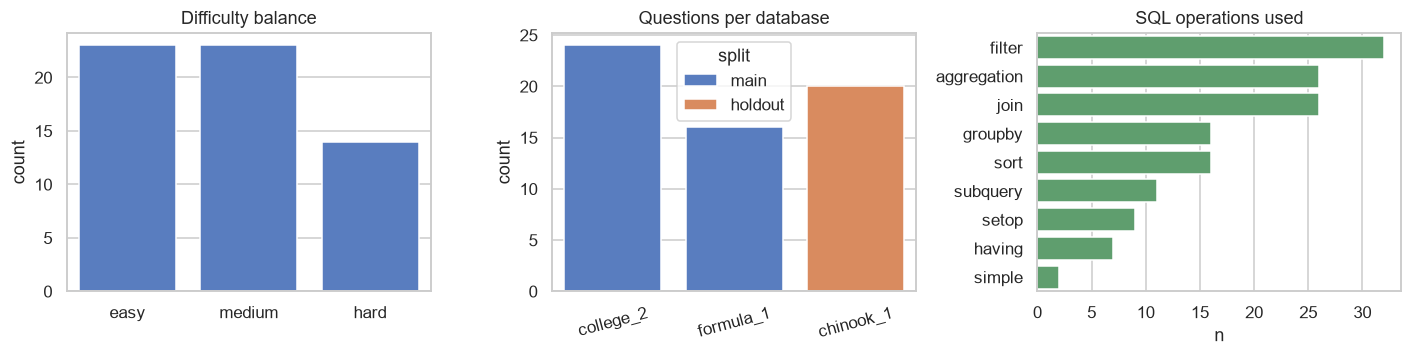

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

order = ["easy", "medium", "hard"]
sns.countplot(tasks, x="difficulty", order=order, ax=axes[0])
axes[0].set_title("Difficulty balance"); axes[0].set_xlabel("")

sns.countplot(tasks, x="db", hue="split", ax=axes[1])
axes[1].set_title("Questions per database"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

tag_counts = Counter(t for tags in tasks.tags for t in tags)
tag_df = pd.DataFrame(tag_counts.most_common(), columns=["tag", "n"])
sns.barplot(tag_df, y="tag", x="n", ax=axes[2], color="#55A868")
axes[2].set_title("SQL operations used"); axes[2].set_ylabel("")

plt.tight_layout(); plt.show()

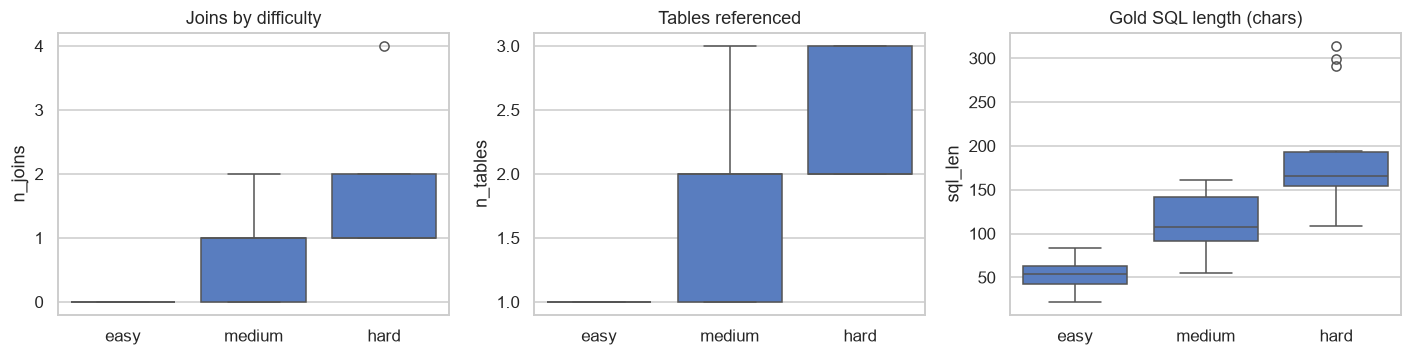

            n_joins  n_tables  sql_len
difficulty                            
easy           0.00      1.00    55.22
medium         0.61      1.65   111.87
hard           1.57      2.43   189.07


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

sns.boxplot(tasks, x="difficulty", y="n_joins", order=order, ax=axes[0])
axes[0].set_title("Joins by difficulty"); axes[0].set_xlabel("")

sns.boxplot(tasks, x="difficulty", y="n_tables", order=order, ax=axes[1])
axes[1].set_title("Tables referenced"); axes[1].set_xlabel("")

tasks["sql_len"] = tasks.gold_sql.str.len()
sns.boxplot(tasks, x="difficulty", y="sql_len", order=order, ax=axes[2])
axes[2].set_title("Gold SQL length (chars)"); axes[2].set_xlabel("")

plt.tight_layout(); plt.show()

print(tasks.groupby("difficulty")[["n_joins", "n_tables", "sql_len"]]
      .mean().round(2).reindex(order).to_string())

**Read this carefully.** If `hard` questions do not use more joins and longer
SQL than `easy` ones, the difficulty label is noise and every per-difficulty
result later in the project is meaningless. The boxplots above are the sanity
check.

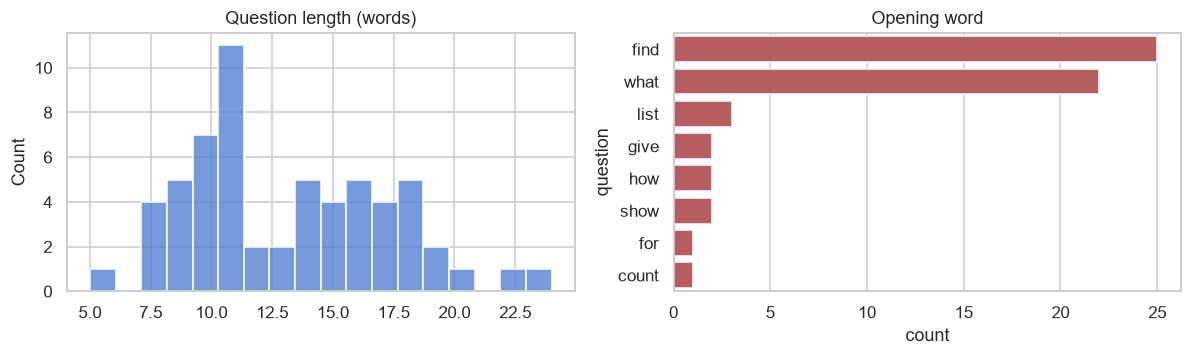

Median question: 12 words


In [9]:
# Question phrasing — what the agent actually has to parse
tasks["q_words"] = tasks.question.str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.histplot(tasks, x="q_words", bins=18, ax=axes[0])
axes[0].set_title("Question length (words)"); axes[0].set_xlabel("")

first = tasks.question.str.split().str[0].str.lower()
sns.barplot(x=first.value_counts().head(8).values,
            y=first.value_counts().head(8).index, ax=axes[1], color="#C44E52")
axes[1].set_title("Opening word"); axes[1].set_xlabel("count")

plt.tight_layout(); plt.show()
print(f"Median question: {tasks.q_words.median():.0f} words")

---
## 4. Are the domains actually different?

The generalisation experiment trains the critic on `formula_1` + `college_2`
and tests it on `chinook_1`. That only means something if the holdout domain is
genuinely unlike the training domains.

Two checks: vocabulary overlap between schemas, and whether the SQL *shapes*
are comparable (they should be — it is the vocabulary that must differ, not the
query structure).

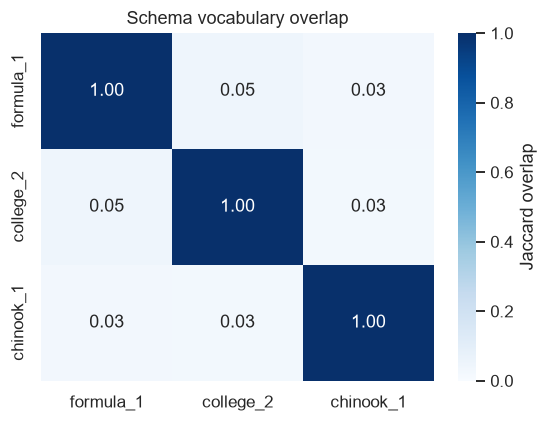

Shared words between the two training DBs and the holdout:
  ['country', 'milliseconds', 'name', 'title']


In [10]:
def vocab(db):
    s = schemas[db]
    words = set()
    for t, info in s["tables"].items():
        words |= set(re.split(r"[_\s]+", t.lower()))
        for c in info["columns"]:
            words |= set(re.split(r"[_\s]+", c["name"].lower()))
    return {w for w in words if len(w) > 2}

V = {db: vocab(db) for db in schemas}

names = list(V)
M = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        inter, union = len(V[a] & V[b]), len(V[a] | V[b])
        M.loc[a, b] = inter / union if union else 0

fig, ax = plt.subplots(figsize=(5.2, 4))
sns.heatmap(M.astype(float), annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Jaccard overlap"})
ax.set_title("Schema vocabulary overlap")
plt.tight_layout(); plt.show()

print("Shared words between the two training DBs and the holdout:")
train_v = V["formula_1"] | V["college_2"]
print(" ", sorted(train_v & V["chinook_1"])[:20])

        n_joins       n_tables       sql_len       
           mean   std     mean   std    mean    std
split                                              
holdout    0.75  0.91     1.65  0.59   97.75  61.90
main       0.52  0.78     1.55  0.78  113.38  64.38


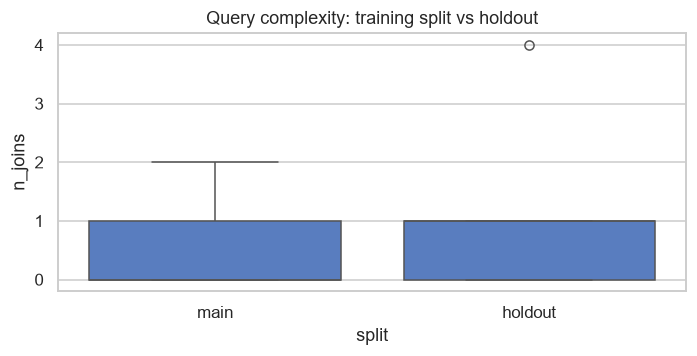

In [11]:
# SQL shape should be comparable across splits — only the words differ
comp = (tasks.groupby("split")[["n_joins", "n_tables", "sql_len"]]
        .agg(["mean", "std"]).round(2))
print(comp.to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.4))
sns.boxplot(tasks, x="split", y="n_joins", ax=ax)
ax.set_title("Query complexity: training split vs holdout")
plt.tight_layout(); plt.show()

**What we want to see.** Low vocabulary overlap (the domains are different)
but similar join and table counts (the queries are comparably hard). That
combination means a drop in critic performance on the holdout can be attributed
to *domain shift* rather than to the holdout simply being harder.

---
## 5. Sanity check — run the gold SQL

Every question was verified to execute during curation, but verifying by hand is
what catches a question whose gold SQL runs and returns something nonsensical.

In [12]:
def run_gold(task, limit=5):
    con = sqlite3.connect(f'file:{DB_DIR / (task["db"] + ".db")}?mode=ro', uri=True)
    try:
        df = pd.read_sql_query(task["gold_sql"], con)
    finally:
        con.close()
    return df.head(limit), len(df)

for _, t in tasks.sample(4, random_state=7).iterrows():
    df, n = run_gold(t)
    print(f'[{t.task_id}] {t.difficulty:<6} {t.db}')
    print(f'  Q: {t.question}')
    print(f'  -> {n} rows')
    print(df.to_string(index=False, max_colwidth=28))
    print()

[t032] easy   formula_1
  Q: List the forenames of all distinct drivers in alphabetical order?
  -> 466 rows
forename
   Adolf
  Adolfo
  Adrian
 Adri��n
   Aguri

[t021] medium college_2
  Q: Find the salaries of all distinct instructors that are less than the largest salary.
  -> 49 rows
   salary
 94333.99
 59303.62
119921.41
 88791.45
 61387.56

[h020] medium chinook_1
  Q: Find the number of albums by the artist "Metallica".
  -> 1 rows
 COUNT(*)
       10

[t018] easy   college_2
  Q: What is the name of the student who has the highest total credits in the History department.
  -> 1 rows
 name
Cadis



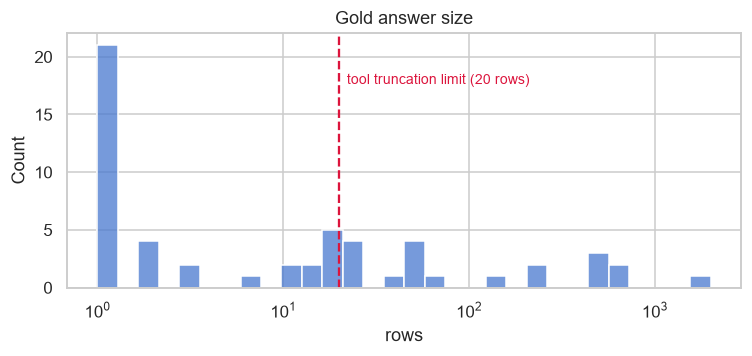

19 of 60 questions return more than 20 rows (32%) — these are the ones where truncation matters.
Largest result: 2,000 rows


In [13]:
# How large are gold result sets? Anything huge must be truncated by the tool.
sizes = []
for _, t in tasks.iterrows():
    try:
        _, n = run_gold(t, limit=0)
        sizes.append({"task_id": t.task_id, "difficulty": t.difficulty, "rows": n})
    except Exception as e:
        sizes.append({"task_id": t.task_id, "difficulty": t.difficulty, "rows": -1})

res = pd.DataFrame(sizes)
fig, ax = plt.subplots(figsize=(7, 3.4))
sns.histplot(res[res.rows >= 0], x="rows", bins=30, log_scale=(True, False), ax=ax)
ax.axvline(20, ls="--", c="crimson")
ax.text(22, ax.get_ylim()[1]*0.8, "tool truncation limit (20 rows)",
        color="crimson", fontsize=9)
ax.set_title("Gold answer size")
plt.tight_layout(); plt.show()

over = (res.rows > 20).sum()
print(f"{over} of {len(res)} questions return more than 20 rows "
      f"({100*over/len(res):.0f}%) — these are the ones where truncation matters.")
print(f"Largest result: {res.rows.max():,} rows")

---
## Summary

| Question | Answer |
|---|---|
| Databases | 3 separate SQLite files, unrelated domains |
| Tables | 11–13 each, 35 if merged (rejected) |
| Schema cost | see §2 — the reason we did not merge |
| Questions | 60 (40 training, 20 holdout) |
| Gold SQL verified | 100% execute |
| Domain separation | see §4 heatmap |

### What this changes

1. **Separate databases confirmed** — merging would spend a large share of the
   context budget on irrelevant schema, on every step.
2. **`get_schema(table)` is worth building** — §2 quantifies the saving. This
   gives layer C's knowledge graph a concrete consumer.
3. **Tool truncation is not optional** — §5 shows how many questions return
   more than 20 rows.
4. **The holdout split is valid** — low vocabulary overlap, comparable query
   complexity.

### Next

`02_trajectory_features.ipynb` — once the agent has produced real runs. That
notebook does the feature engineering for the critic: error counts, retry
structure, query complexity, context pressure. It cannot be written honestly
until the trajectories exist.